# E-Commerce Customer Market Segmentation

---

## Overview

A UK-based e-commerce store has thousands of customers — but treats them all the same. This project segments customers into distinct groups based on their buying behaviour, so the business can personalise its strategy for each group.

We use **RFM Analysis** to score each customer, **K-Means Clustering** to discover segments, and a **Random Forest classifier** to predict which segment a new customer belongs to.

---

## Dataset — Raw Features

Each row is one product line within a transaction. A single order can have multiple rows.

| Feature | Description |
|---|---|
| `InvoiceNo` | Transaction ID. Prefix `C` = cancellation |
| `StockCode` | Product code |
| `Description` | Product name |
| `Quantity` | Units bought. Negative = returned |
| `InvoiceDate` | Date and time of transaction |
| `UnitPrice` | Price per unit (£) |
| `CustomerID` | Customer ID. Nulls = guest checkouts |
| `Country` | Customer's country |

---

## Engineered Features

| Feature | Description |
|---|---|
| `Total_Price` | `Quantity × UnitPrice` |
| `Year`, `Month`, `Day`, `Hour`, `Day_of_Week` | Temporal features from `InvoiceDate` |
| `ReturnCount` | Number of returns per customer |
| `Recency` | Days since last purchase |
| `Frequency` | Number of unique orders placed |
| `Monetary` | Total spend across all orders |
| `Cluster_Label` | Final segment assigned by the model |

---

## Pipeline

```
Raw Data → Cleaning → EDA → RFM Table → Pre-processing → K-Means → Classification
```

---

*Tools: Python · Pandas · NumPy · Scikit-learn · Matplotlib · Seaborn · LightGBM*

In [1]:
import pandas as pd
import numpy as np
import re
import warnings

# Configuration: Ignore warnings for a clean notebook output
warnings.filterwarnings('ignore')

In [2]:
# Loading the dataset and storing raw data safely
dataset = pd.read_csv('data.csv', encoding='ISO-8859-1')
data = dataset.copy()

# Initial Data Type Audit
print("--- Initial Data Types ---")
print(dataset.info())

--- Initial Data Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB
None


In [3]:
# Checking Rows and Columns
print("Before Cleaning :", dataset.shape)

Before Cleaning : (541909, 8)


In [4]:
# Checking the Null values in raw data
dataset.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [5]:
# Viewing the first few rows to confirm loading
print('Before Cleaning Data :')
dataset.head()

Before Cleaning Data :


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [6]:
# Viewing the last few rows to confirm loading
print('Before Cleaning Data :')
dataset.tail()

Before Cleaning Data :


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,12/9/2011 12:50,4.95,12680.0,France


In [ ]:
"""
    Cleaning e-commerce transaction data for customer segmentation.
    Handleing nulls, standardizes text, formating datatypes, captures returns, 
    and removes transactional noise.
"""

def clean_ecommerce_data(df):
    
    df_clean = df.copy()
    initial_shape = df_clean.shape
    
    # We must capture return counts BEFORE dropping negative quantities.
    # We will temporarily drop null CustomerIDs here just for the count.
    returns_df = df_clean[(df_clean['Quantity'] < 0) & (df_clean['CustomerID'].notnull())]
    returns_df['CustomerID'] = returns_df['CustomerID'].astype(int).astype(str)
    return_counts = returns_df.groupby('CustomerID').size().to_dict()

    # 1  Drop Null CustomerIDs 
    # We cannot segment a customer if we don't know who they are.
    df_clean = df_clean.dropna(subset=['CustomerID'])
    
    # 2. Remove duplicates
    df_clean = df_clean.drop_duplicates()
    
    # --- DOMAIN SPECIFIC: Filter Non-Product Transactions ---
    # Remove rows where StockCode is entirely alphabetic (e.g., 'POST', 'D', 'M')
    # This prevents shipping/bank charges from skewing customer value.
    df_clean = df_clean[~df_clean['StockCode'].astype(str).str.match(r'^[A-Za-z]+$')]
    
    # 3. Clean StockCode (Remove alphabets attached to numeric codes)
    # Replaces any uppercase or lowercase letter with nothing.
    df_clean['StockCode'] = df_clean['StockCode'].astype(str).str.replace(r'[a-zA-Z]', '', regex=True)
    
    # 4. Standardize Description
    # Strip leading/trailing spaces and make everything lowercase
    df_clean['Description'] = df_clean['Description'].astype(str).str.strip().str.lower()
    
    # 5. Data type correction for InvoiceDate
    df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
    
    # 6. Convert CustomerID: float -> int -> str (removes the .0)
    df_clean['CustomerID'] = df_clean['CustomerID'].astype(int).astype(str)
    
    # Map the return counts back as a new feature for future clustering
    df_clean['ReturnCount'] = df_clean['CustomerID'].map(return_counts).fillna(0).astype(int)
    
    # 7. Filter Transactional Noise (Positive quantities and prices only)
    df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]
    
    final_shape = df_clean.shape
    
    # --- Generate Cleaning Report ---
    print("\n" + "="*40)
    print("        DATA CLEANING REPORT")
    print("="*40)
    print(f"Initial Rows         : {initial_shape[0]}")
    print(f"Final Cleaned Rows   : {final_shape[0]}")
    print(f"Total Rows Removed   : {initial_shape[0] - final_shape[0]}")
    print("-" * 40)
    print("Transformations Applied:")
    print(" Captured 'ReturnCount' feature per customer.")
    print(" Dropped rows missing CustomerID.")
    print(" Removed exact duplicate rows.")
    print(" Filtered out non-product noise (e.g., POST, M).")
    print(" Stripped alphabetic characters from StockCode.")
    print(" Standardized Descriptions (lowercase, stripped spaces).")
    print(" Converted InvoiceDate to Datetime.")
    print(" Casted CustomerID to String (removed decimals).")
    print(" Filtered out negative/zero Quantities and UnitPrices.")
    print("="*40 + "\n")
    
    return df_clean

# Apply the function to your dataset
cleaned_data = clean_ecommerce_data(data)

# Separate columns based on their data types
numerical_cols = cleaned_data.select_dtypes(include=['int64', 'int32', 'float64']).columns.tolist()
categorical_cols = cleaned_data.select_dtypes(include=['object']).columns.tolist()
datetime_cols = cleaned_data.select_dtypes(include=['datetime64[ns]']).columns.tolist()

print("Numerical Columns  :", numerical_cols)
print("Categorical Columns:", categorical_cols)
print("Datetime Columns   :", datetime_cols)


        DATA CLEANING REPORT
Initial Rows         : 541909
Final Cleaned Rows   : 391295
Total Rows Removed   : 150614
----------------------------------------
Transformations Applied:
 Captured 'ReturnCount' feature per customer.
 Dropped rows missing CustomerID.
 Removed exact duplicate rows.
 Filtered out non-product noise (e.g., POST, M).
 Stripped alphabetic characters from StockCode.
 Standardized Descriptions (lowercase, stripped spaces).
 Converted InvoiceDate to Datetime.
 Casted CustomerID to String (removed decimals).
 Filtered out negative/zero Quantities and UnitPrices.

Numerical Columns  : ['Quantity', 'UnitPrice', 'ReturnCount']
Categorical Columns: ['InvoiceNo', 'StockCode', 'Description', 'CustomerID', 'Country']
Datetime Columns   : ['InvoiceDate']


In [8]:
print('Data after Cleaned:  ')
print("" + "="*40)
cleaned_data

Data after Cleaned:  


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,ReturnCount
0,536365,85123,white hanging heart t-light holder,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15
1,536365,71053,white metal lantern,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,15
2,536365,84406,cream cupid hearts coat hanger,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,15
3,536365,84029,knitted union flag hot water bottle,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,15
4,536365,84029,red woolly hottie white heart.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,15
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,pack of 20 spaceboy napkins,12,2011-12-09 12:50:00,0.85,12680,France,0
541905,581587,22899,children's apron dolly girl,6,2011-12-09 12:50:00,2.10,12680,France,0
541906,581587,23254,childrens cutlery dolly girl,4,2011-12-09 12:50:00,4.15,12680,France,0
541907,581587,23255,childrens cutlery circus parade,4,2011-12-09 12:50:00,4.15,12680,France,0


In [9]:
# Checking for the How many customers are there totally (Unique Customers)
cleaned_data['CustomerID'].nunique()    

4335

In [10]:
# Function for extraction the Feature called Total_Price,
# and Extracting the Temporal Features called Year, Month, Day, Hour.  

def feature_extraction(df):

    # creating a copy to keep transformation isolated
    df_features = df.copy()

    # Calculating total price and crating an new column
    df_features['Total_Price'] = df_features['Quantity'] * df_features['UnitPrice']

    # Extracting the Temporal features
    df_features['Year'] = df_features['InvoiceDate'].dt.year 
    df_features['Month'] = df_features['InvoiceDate'].dt.month 
    df_features['Day'] = df_features['InvoiceDate'].dt.day 
    df_features['Hour'] = df_features['InvoiceDate'].dt.hour

    # extracting the day of week temporal feature
    df_features['Day_of_Week'] = df_features['InvoiceDate'].dt.day_name()

    # Removing the time from the invocedate colume
    df_features['InvoiceDate'] = df_features['InvoiceDate'].dt.normalize()

    # --- Generate Feature Engineering Report ---
    print("\n" + "="*45)
    print("      FEATURE ENGINEERING REPORT")
    print("="*45)
    print("New Features Added:")
    print(" ✔ 'Total_Price' (Quantity * UnitPrice)")
    print(" ✔ 'Year', 'Month', 'Day', 'Hour'")
    print(" ✔ 'Day_of_Week' (String names for plotting)")
    print(" ✔ 'Invoice_Date_Only' (For future RFM Snapshot)")
    print("-" * 45)
    print(f"Current DataFrame Shape: {df_features.shape}")
    print("="*45 + "\n")

    return df_features

# applying my cleaned dat to the fuction
engineered_data = feature_extraction(cleaned_data)

# Data after Feature Engineering

engineered_data.head()




      FEATURE ENGINEERING REPORT
New Features Added:
 ✔ 'Total_Price' (Quantity * UnitPrice)
 ✔ 'Year', 'Month', 'Day', 'Hour'
 ✔ 'Day_of_Week' (String names for plotting)
 ✔ 'Invoice_Date_Only' (For future RFM Snapshot)
---------------------------------------------
Current DataFrame Shape: (391295, 15)



,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,ReturnCount,Total_Price,Year,Month,Day,Hour,Day_of_Week
0,536365,85123,white hanging heart t-light holder,6,2010-12-01,2.55,17850,United Kingdom,15,15.30,2010,12,1,8,Wednesday
1,536365,71053,white metal lantern,6,2010-12-01,3.39,17850,United Kingdom,15,20.34,2010,12,1,8,Wednesday
2,536365,84406,cream cupid hearts coat hanger,8,2010-12-01,2.75,17850,United Kingdom,15,22.00,2010,12,1,8,Wednesday
3,536365,84029,knitted union flag hot water bottle,6,2010-12-01,3.39,17850,United Kingdom,15,20.34,2010,12,1,8,Wednesday
4,536365,84029,red woolly hottie white heart.,6,2010-12-01,3.39,17850,United Kingdom,15,20.34,2010,12,1,8,Wednesday


# Exploratory Data Analysis

---

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Global Design Settings ---
sns.set_style("whitegrid")  # Clean, distraction-free background
plt.rcParams['figure.figsize'] = (14, 6) # Wide 14x6 canvas for better readability
plt.rcParams['font.size'] = 12 # Readable font size for presentations
plt.rcParams['axes.titlesize'] = 16 # Large titles
plt.rcParams['axes.titleweight'] = 'bold' # Bold titles for emphasis

## 1. Univariate Analysis — *The "What" & "Where"*

**Business Question:** What are our best-selling products and key markets?

**Plot 1 — Top 10 Best-Selling Products** *(Bar Chart)*
Identifies the hero products driving the most transactions. Useful for inventory and stocking decisions.

**Plot 2 — Top 10 Markets by Transaction Volume** *(Bar Chart)*
The UK dominates with ~96% of all transactions, confirming this is a primarily domestic business.

---

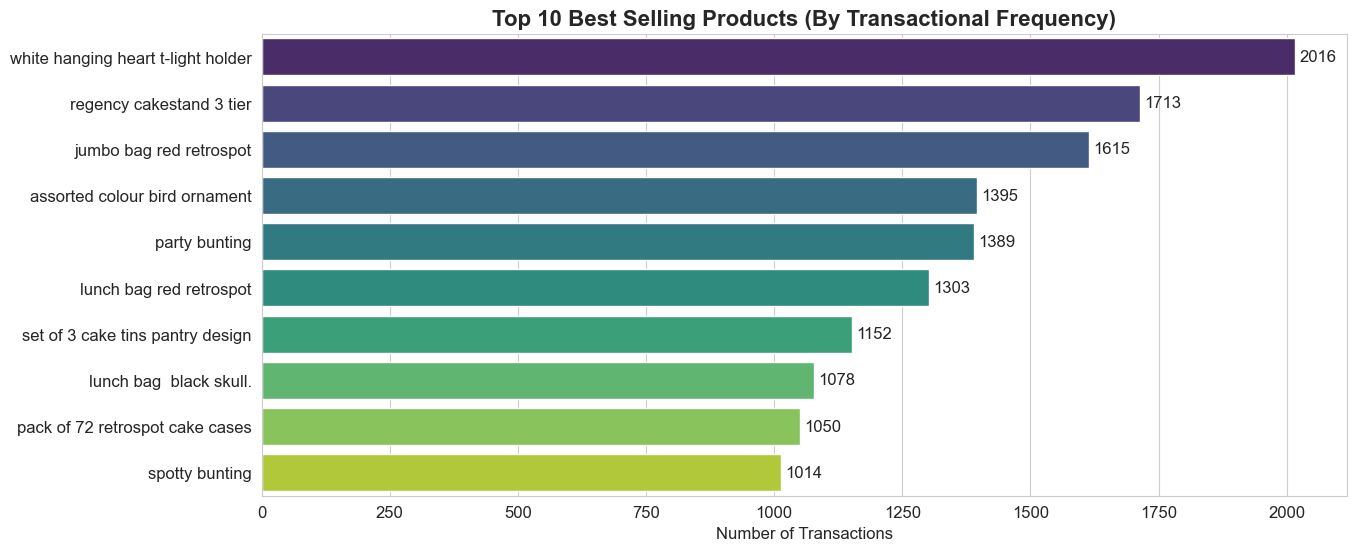

In [12]:
# --- Plot 1: Top 10 Best-Selling Products ---

plt.figure()
top_products = engineered_data['Description'].value_counts().head(10)
ax = sns.barplot(x = top_products.values, y = top_products.index, palette = 'viridis')

plt.title('Top 10 Best Selling Products (By Transactional Frequency)')
plt.xlabel('Number of Transactions')
plt.ylabel('')

# Add data labels to the end of bars for precision
for i in ax.containers:
    ax.bar_label(i, padding=3)

plt.show()

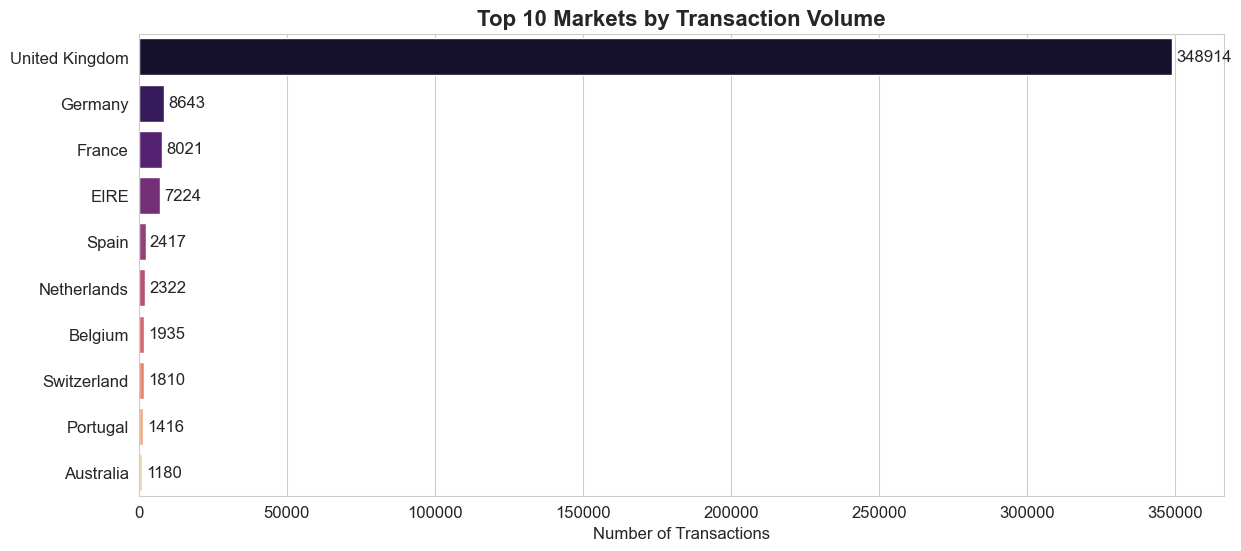

In [13]:
# --- Plot 2: Top 10 Markets (Countries) ---

plt.figure()
top_countries = engineered_data['Country'].value_counts().head(10)
ax = sns.barplot(x=top_countries.values, y=top_countries.index, palette='magma')

plt.title('Top 10 Markets by Transaction Volume')
plt.xlabel('Number of Transactions')
plt.ylabel('')

# Add data labels
for i in ax.containers:
    ax.bar_label(i, padding=3)
plt.show()

## 2. Bivariate Analysis — *The "When"*

**Business Question:** Is revenue consistent year-round, or are we a seasonal business?

**Plot 3 — Monthly Revenue Trend** *(Line Chart)*
Revenue spikes towards November–December, confirming a holiday gifting-driven business. Operations should ramp up inventory in October.

**Business Question:** When are customers most active during the day?

**Plot 4 — Store Traffic by Hour of Day** *(Bar Chart)*
Peak traffic is at **12 PM**, suggesting customers shop during lunch breaks — the ideal window for flash sales and push notifications.

---

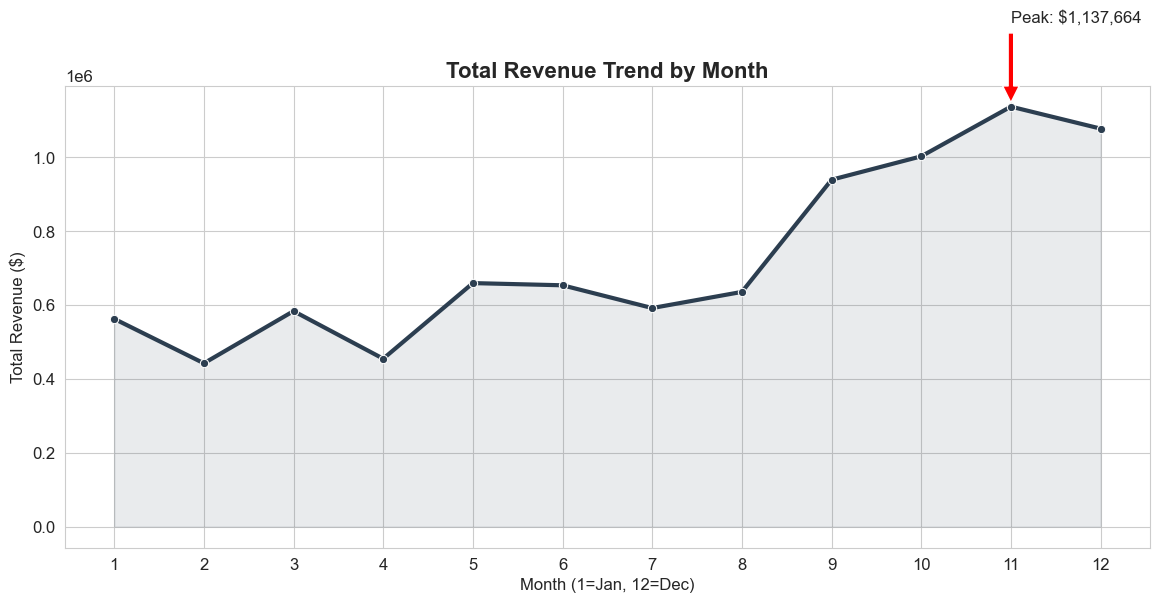

In [14]:
# --- Plot 3: Monthly Revenue Trend ---
# Group by Month and sum the revenue
monthly_sales = engineered_data.groupby('Month')['Total_Price'].sum()

plt.figure()
sns.lineplot(x=monthly_sales.index, y=monthly_sales.values, marker='o', linewidth=3, color='#2c3e50')
plt.fill_between(monthly_sales.index, monthly_sales.values, color='#2c3e50', alpha=0.1) # Shading for visual weight

plt.title('Total Revenue Trend by Month')
plt.xlabel('Month (1=Jan, 12=Dec)')
plt.ylabel('Total Revenue ($)')
plt.xticks(range(1, 13)) # Ensure all 12 months are shown

# Annotate the Peak Month automatically
peak_month = monthly_sales.idxmax()
peak_val = monthly_sales.max()
plt.annotate(f'Peak: ${peak_val:,.0f}', 
             xy=(peak_month, peak_val), 
             xytext=(peak_month, peak_val*1.2),
             arrowprops=dict(facecolor='red', shrink=0.05))
plt.show()

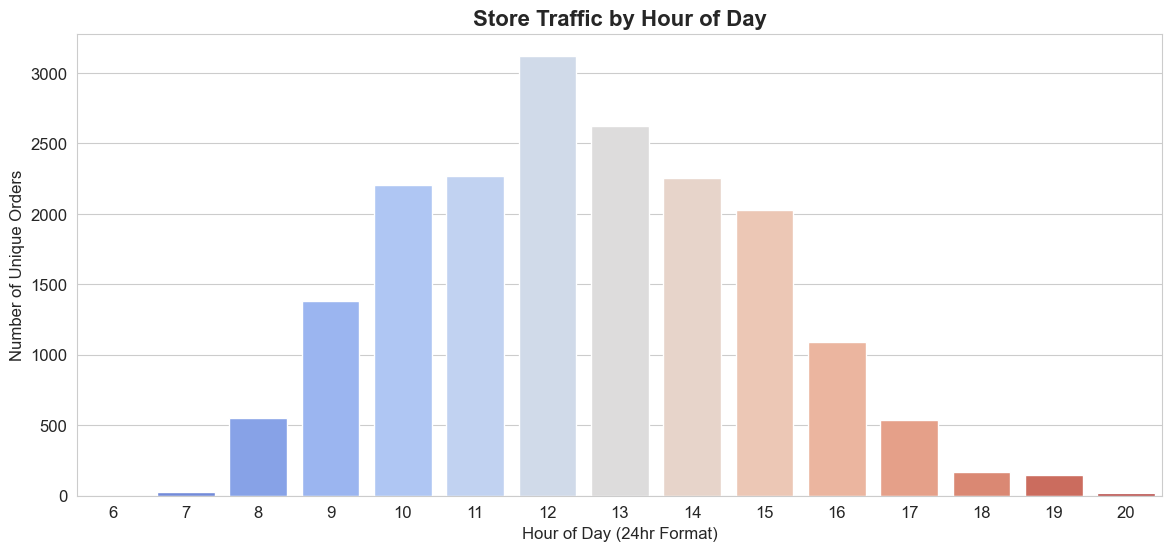

In [15]:
# --- Plot 4: Hourly Traffic ---
# We count unique InvoiceNo to see how many *orders* are placed, not just items
hourly_traffic = engineered_data.groupby('Hour')['InvoiceNo'].nunique()

plt.figure()
sns.barplot(x=hourly_traffic.index, y=hourly_traffic.values, palette='coolwarm')

plt.title('Store Traffic by Hour of Day')
plt.xlabel('Hour of Day (24hr Format)')
plt.ylabel('Number of Unique Orders')
plt.show()

## 3. Multivariate Analysis — *The "Golden Window"*

**Business Question:** Is there a specific day-time combination that drives the most orders?

**Plot 5 — Shopping Activity Heatmap: Day vs. Hour** *(Heatmap)*
The intersection of day and hour reveals exact "golden windows" — the best moments to trigger marketing campaigns for maximum conversion.

---

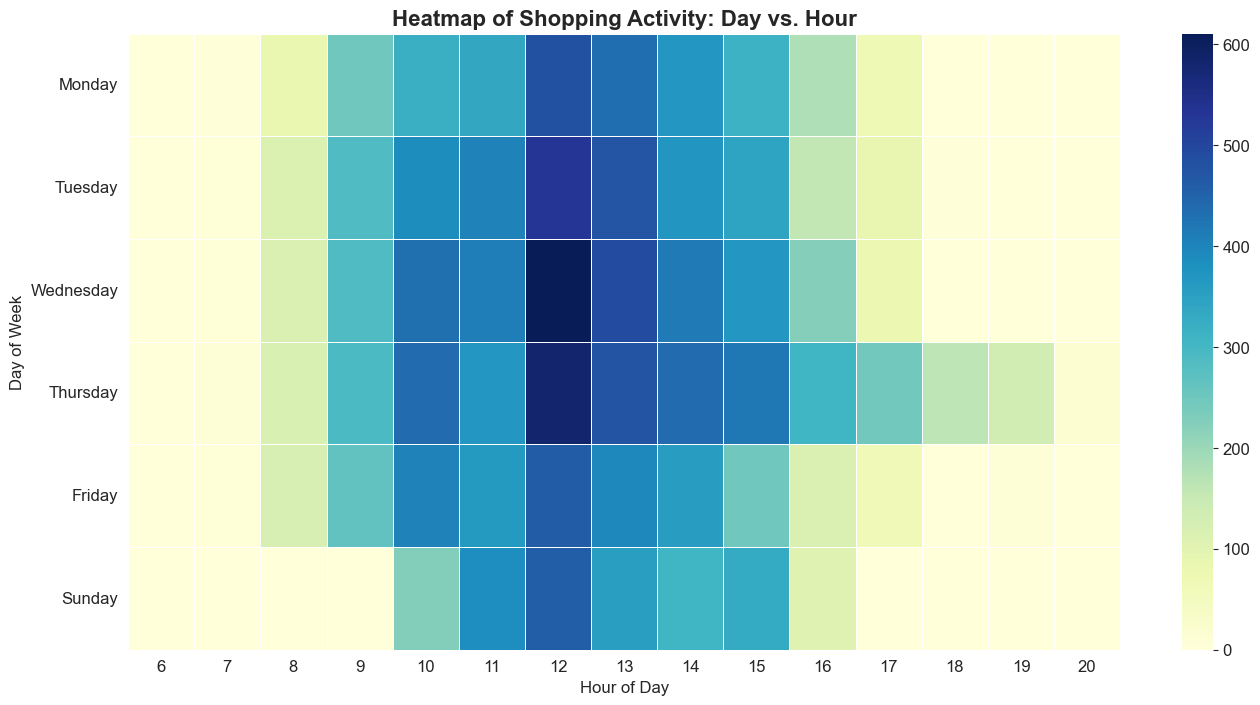

In [16]:
# --- Plot 5: Activity Heatmap (Day vs. Hour) ---
# Create a matrix: Rows=Day, Cols=Hour, Values=Unique Order Counts
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Sunday'] 
activity_matrix = engineered_data.groupby(['Day_of_Week', 'Hour'])['InvoiceNo'].nunique().unstack().fillna(0)
activity_matrix = activity_matrix.reindex(days_order) # Sort rows comfortably

plt.figure(figsize=(16, 8))
sns.heatmap(activity_matrix, cmap='YlGnBu', annot=False, linewidths=.5)

plt.title('Heatmap of Shopping Activity: Day vs. Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.yticks(rotation=0) # Keep day names horizontal for readability
plt.show()

## RFM Table Generation

In [17]:
"""
    Aggregates transaction data into a customer-level RFM table.
    
    Logic:
    - Recency: Days since last purchase (Snapshot Date - Last Invoice Date)
    - Frequency: Number of unique transactions (Count of InvoiceNo)
    - Monetary: Total money spent (Sum of Total_Price)
"""

def rfm_table(df):

    # 1. Calculate the Snapshot Date (The "Anchor")
    # We take the very last transaction in the dataset and add 1 day
    # to ensure the Recency for the most recent purchase is 1, not 0.
    snapshot_date = df['InvoiceDate'].max() + pd.to_timedelta(1, unit='D')
    
    # 2. Group by CustomerID and calculate RFM metrics
    rfm = df.groupby('CustomerID').agg({
        'InvoiceDate': lambda x: (snapshot_date - x.max()).days, # Recency calculation
        'InvoiceNo': 'nunique',                                  # Frequency (count unique orders)
        'Total_Price': 'sum'                                     # Monetary (sum of spend)
    })
    
    # 3. Rename columns for standard RFM terminology
    rfm.rename(columns={
        'InvoiceDate': 'Recency',
        'InvoiceNo': 'Frequency',
        'Total_Price': 'Monetary'
    }, inplace=True)
    
    # --- Generate RFM Report ---
    print("\n" + "="*40)
    print("      RFM TABLE GENERATION REPORT")
    print("="*40)
    print(f"Snapshot Date Used   : {snapshot_date}")
    print(f"Total Customers      : {rfm.shape[0]}")
    print("-" * 40)
    print("Sample of the first 5 customers:")
    print(rfm.head())
    print("="*40 + "\n")
    
    return rfm

# Applyong our engineered data to the rfm table function
rfm_data = rfm_table(engineered_data)

rfm_data.head()


      RFM TABLE GENERATION REPORT
Snapshot Date Used   : 2011-12-10 00:00:00
Total Customers      : 4335
----------------------------------------
Sample of the first 5 customers:
            Recency  Frequency  Monetary
CustomerID                              
12346           326          1  77183.60
12347             3          7   4310.00
12348            76          4   1437.24
12349            19          1   1457.55
12350           311          1    294.40



,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,3,7,4310.00
12348,76,4,1437.24
12349,19,1,1457.55
12350,311,1,294.40


In [ ]:
# # Reset index so 'CustomerID' becomes a column, not an index
# rfm_export = rfm_data.reset_index() if 'CustomerID' not in rfm_data.columns else rfm_data

# # Save only the essential columns for the model
# rfm_export[['CustomerID', 'Recency', 'Frequency', 'Monetary']].to_csv("rfm_data_before_clustering.csv", index=False)

# print("✅ 'rfm_data_before_clustering.csv' saved with 'CustomerID' as a column.")

✅ 'rfm_data_before_clustering.csv' saved with 'CustomerID' as a column.


## 4. RFM Analysis — *Understanding Customer Behaviour*

**Business Question:** Do we have extreme spenders distorting our averages?

**Plot  1— RFM Distribution Boxplots** *(Boxplots — R, F, M side by side)*
All three features show extreme right-skewness. A tiny fraction of wholesale buyers spend upwards of £50,000+, while the majority cluster at the low end. This proves we cannot feed raw RFM directly into K-Means.

**Business Question:** Does buying more frequently mean spending more?

**Plot 2 — Frequency vs. Monetary Scatter Plot** *(Scatter)*
A general upward trend exists, but outliers in the top-right corner crush the rest of the data into an unreadable cluster — further evidence that scaling and outlier handling are essential before clustering.

**Business Question:** Are R, F, and M giving us unique information or repeating each other?

**Plot 3 — RFM Correlation Heatmap** *(Heatmap)*
Frequency and Monetary are strongly correlated (+0.55). Recency is negatively correlated with both — customers who bought recently also buy more often and spend more. The metrics are working as expected.

---

In [ ]:

# --- Global Design Settings ---
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.titleweight'] = 'bold'

Univariate Analysis: Spotting the "Whales" (Boxplots)
Business Question: Do all our customers spend similarly, or do we have extreme VIPs skewing our averages?

Presentation Story: "When we looked at the raw RFM data, we didn't see a normal bell curve.  Instead, we found extreme right-skewness. These boxplots prove that while the vast majority of our customers buy a few times and spend under $1,000, we have a tiny fraction of wholesale buyers spending upwards of $50,000. These are our 'Whales.' This visual proves exactly why we cannot feed this raw data directly into K-Means without scaling it first."

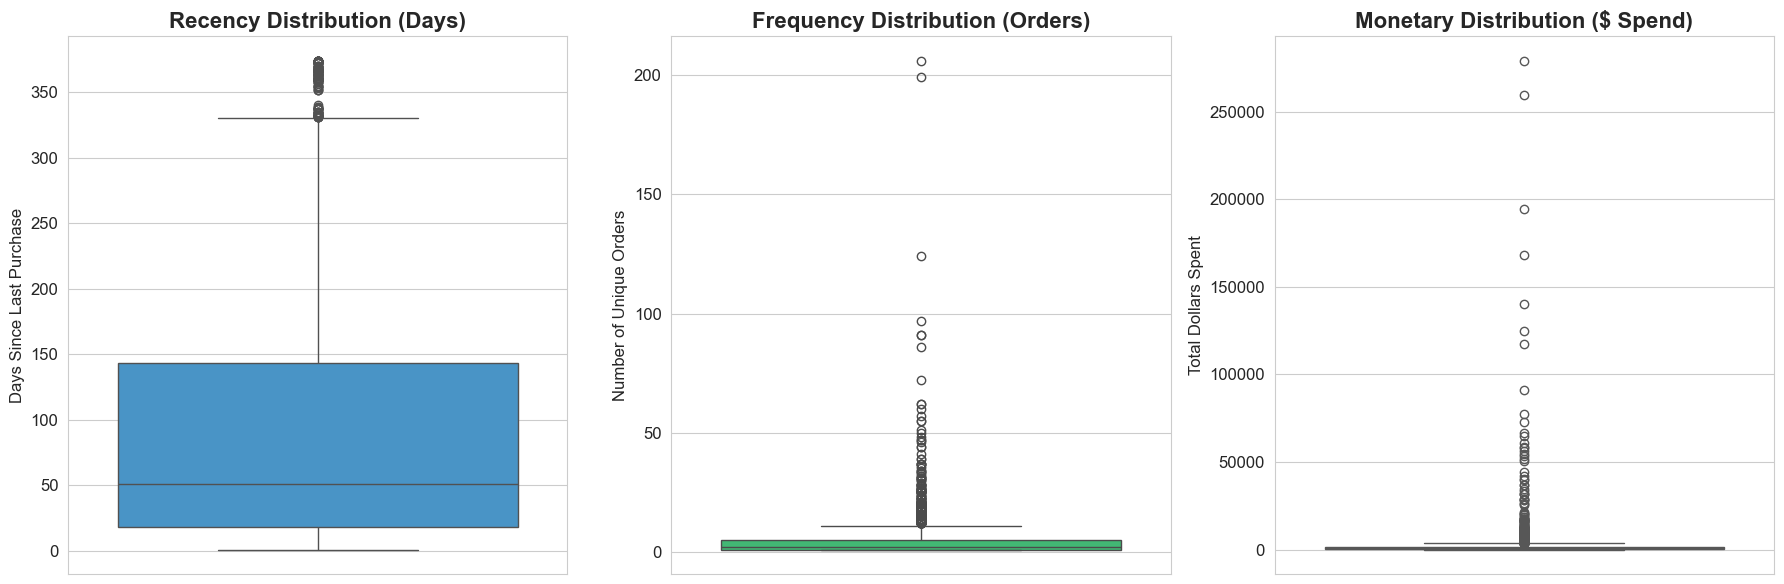

In [19]:
# --- Plot 1: RFM Distribution & Outliers (Boxplots) ---
# We use subplots to put all three charts side-by-side because they have different scales
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Recency Boxplot
sns.boxplot(y=rfm_data['Recency'], ax=axes[0], color='#3498db')
axes[0].set_title('Recency Distribution (Days)')
axes[0].set_ylabel('Days Since Last Purchase')

# Frequency Boxplot
sns.boxplot(y=rfm_data['Frequency'], ax=axes[1], color='#2ecc71')
axes[1].set_title('Frequency Distribution (Orders)')
axes[1].set_ylabel('Number of Unique Orders')

# Monetary Boxplot
sns.boxplot(y=rfm_data['Monetary'], ax=axes[2], color='#e74c3c')
axes[2].set_title('Monetary Distribution ($ Spend)')
axes[2].set_ylabel('Total Dollars Spent')

plt.tight_layout()
plt.show()

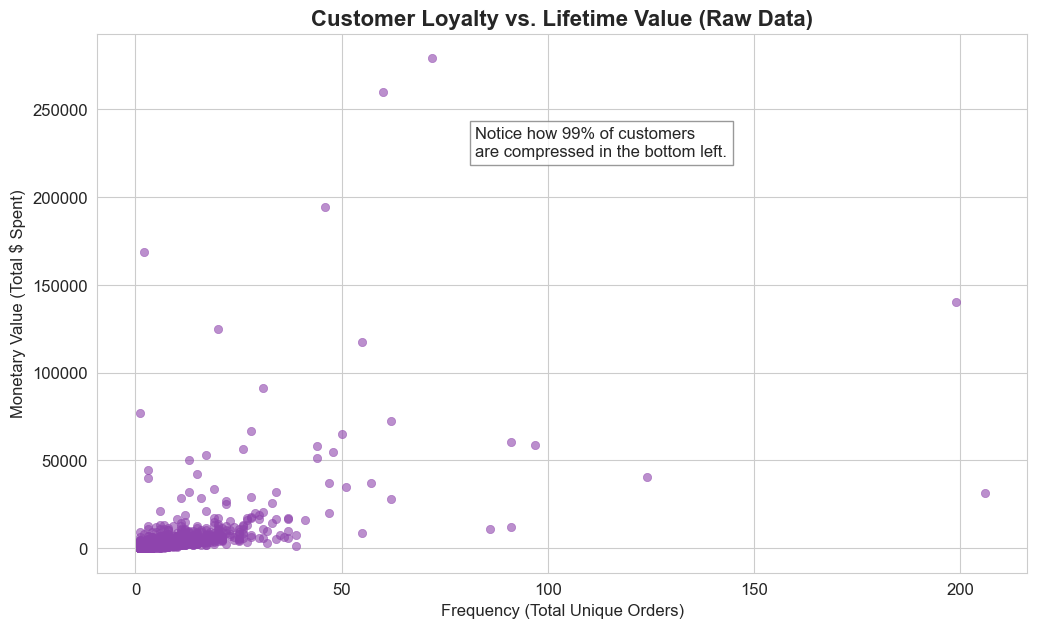

In [20]:
# --- Plot 2: Frequency vs. Monetary Scatter Plot ---
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=rfm_data, 
    x='Frequency', 
    y='Monetary', 
    alpha=0.6,          # Slight transparency to see overlapping points
    edgecolor=None, 
    color='#8e44ad'
)

plt.title('Customer Loyalty vs. Lifetime Value (Raw Data)')
plt.xlabel('Frequency (Total Unique Orders)')
plt.ylabel('Monetary Value (Total $ Spent)')

# Adding a note directly on the plot for the presentation
plt.text(
    x=rfm_data['Frequency'].max() * 0.4, 
    y=rfm_data['Monetary'].max() * 0.8, 
    s="Notice how 99% of customers\nare compressed in the bottom left.", 
    fontsize=12, 
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray')
)

plt.show()

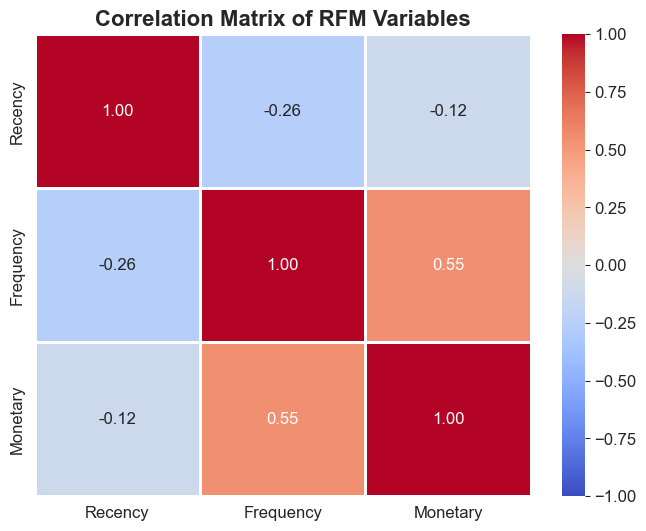

In [21]:
# --- Plot 3: RFM Correlation Heatmap ---
plt.figure(figsize=(8, 6))

# Calculate the correlation matrix
corr_matrix = rfm_data[['Recency', 'Frequency', 'Monetary']].corr()

# Plot the heatmap
sns.heatmap(
    corr_matrix, 
    annot=True,          # Show the actual numbers
    cmap='coolwarm',     # Red for positive, Blue for negative correlation
    fmt='.2f',           # Round to 2 decimal places
    linewidths=1,
    vmin=-1, vmax=1      # Set scale from -1 to 1
)

plt.title('Correlation Matrix of RFM Variables')
plt.show()

1. Isolating the "Whales" (VIP Segmentation)
Presentation Note: "We calculated the 99th percentile for monetary spend. Anyone above this threshold was removed from the algorithmic clustering and manually designated as a 'VIP Segment' for personalized, high-touch marketing."

In [22]:
# Define the 99th percentile threshold for Monetary spend
monetary_threshold = rfm_data['Monetary'].quantile(0.99)

# 1. Isolate the VIPs
vip_customers = rfm_data[rfm_data['Monetary'] >= monetary_threshold].copy()
vip_customers['Cluster_Label'] = 'VIP Segment'

# 2. Keep the core customers for the machine learning model
core_customers = rfm_data[rfm_data['Monetary'] < monetary_threshold].copy()

print(f"VIP Customers Isolated: {len(vip_customers)}")
print(f"Core Customers for ML : {len(core_customers)}")

VIP Customers Isolated: 44
Core Customers for ML : 4291


2. Log Transformation (Compressing the Skew)Presentation Note: "To handle the remaining right-skewness, we applied a $\log(x+1)$ transformation. This compresses the data so the algorithm can compare a standard buyer to a heavy buyer without mathematically breaking."

In [23]:
# Create a copy to store our transformed data
rfm_log = core_customers[['Recency', 'Frequency', 'Monetary']].copy()

# Apply log(x+1) transformation using numpy's log1p
# We use log1p instead of log to avoid errors if a customer has a value of exactly 0
rfm_log['Recency'] = np.log1p(rfm_log['Recency'])
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])
rfm_log['Monetary'] = np.log1p(rfm_log['Monetary'])

print("Log Transformation Applied Successfully.")
print(rfm_log.head())

Log Transformation Applied Successfully.
             Recency  Frequency  Monetary
CustomerID                               
12347       1.386294   2.079442  8.368925
12348       4.343805   1.609438  7.271175
12349       2.995732   0.693147  7.285198
12350       5.743003   0.693147  5.688330
12352       3.637586   2.079442  7.234711


Standard Scaling (Z-Score Normalization)
Presentation Note: "Finally, because K-Means is highly sensitive to the scale of the data, we used Standard Scaler. This forces Days, Counts, and Dollars into a uniform metric with a mean of 0 and standard deviation of 1, giving each feature equal weight."

In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit and transform the log-transformed data
# This returns a numpy array, so we convert it back to a Pandas DataFrame
rfm_scaled_array = scaler.fit_transform(rfm_log)

rfm_scaled = pd.DataFrame(
    rfm_scaled_array, 
    index=rfm_log.index, 
    columns=rfm_log.columns
)

print("\nStandard Scaling Applied Successfully.")
print("Mean of scaled features (should be ~0):")
print(rfm_scaled.mean().round(3))
print("\nStandard Deviation of scaled features (should be ~1):")
print(rfm_scaled.std().round(3))


Standard Scaling Applied Successfully.
Mean of scaled features (should be ~0):
Recency      0.0
Frequency   -0.0
Monetary     0.0
dtype: float64

Standard Deviation of scaled features (should be ~1):
Recency      1.0
Frequency    1.0
Monetary     1.0
dtype: float64


Determining Optimal Clusters (Elbow & Silhouette)
Presentation Note: "To eliminate human bias in choosing the number of segments, we ran K-Means through a range of 2 to 10 clusters. We evaluated the Within-Cluster Sum of Squares (Inertia) to find the 'Elbow' point of diminishing returns, and cross-validated it with the Silhouette Score to ensure maximum mathematical separation between our customer segments."

Running K-Means for multiple values of K. This might take a few seconds...

K=2 | Inertia: 6,295 | Silhouette: 0.432
K=3 | Inertia: 4,750 | Silhouette: 0.330
K=4 | Inertia: 3,797 | Silhouette: 0.335
K=5 | Inertia: 3,190 | Silhouette: 0.317
K=6 | Inertia: 2,748 | Silhouette: 0.313
K=7 | Inertia: 2,478 | Silhouette: 0.304
K=8 | Inertia: 2,270 | Silhouette: 0.279
K=9 | Inertia: 2,085 | Silhouette: 0.282
K=10 | Inertia: 1,936 | Silhouette: 0.279


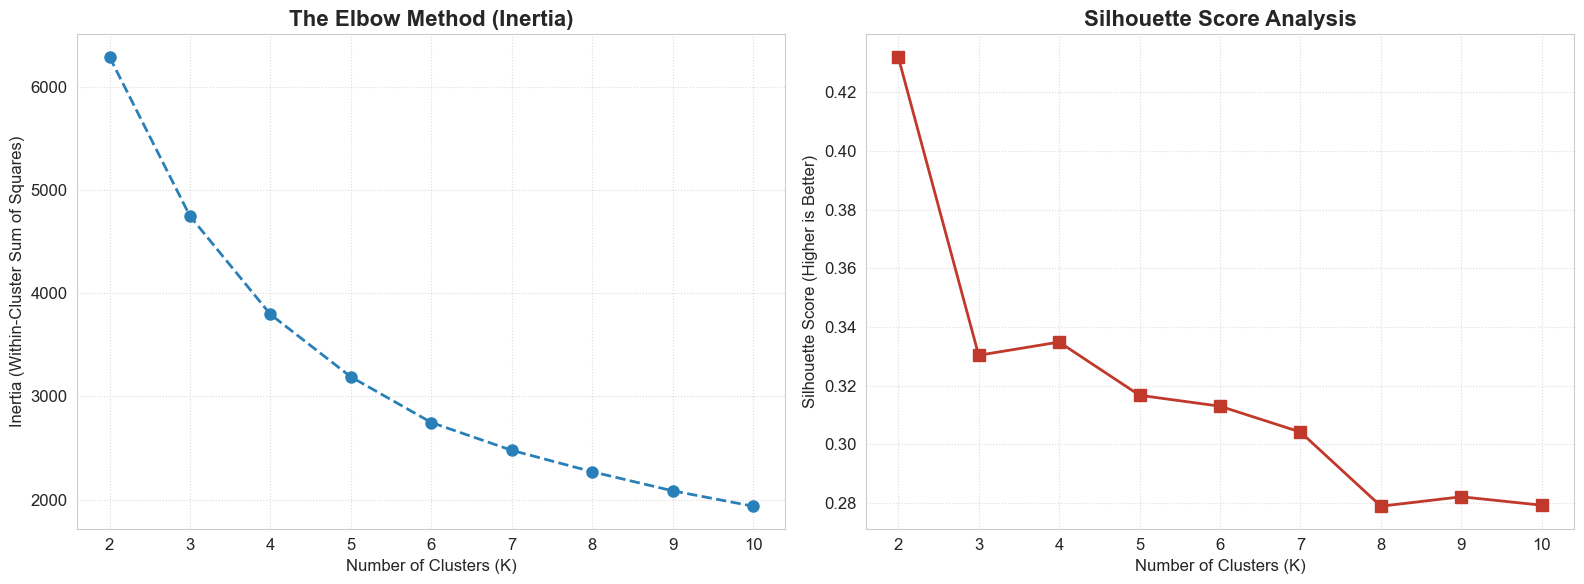

In [25]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Suppress annoying KMeans memory leak warnings on Windows
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

# We will test K values from 2 to 10
k_range = range(2, 11)
inertia_values = []
silhouette_scores = []

print("Running K-Means for multiple values of K. This might take a few seconds...\n")

for k in k_range:
    # 1. Initialize KMeans (random_state ensures we get the exact same results every time)
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, max_iter=300, random_state=42)
    
    # 2. Fit the model to our SCALED data
    kmeans.fit(rfm_scaled)
    
    # 3. Store the Inertia (WCSS) for the Elbow Plot
    inertia_values.append(kmeans.inertia_)
    
    # 4. Calculate and store the Silhouette Score
    # Silhouette requires at least 2 clusters to calculate distance between them
    labels = kmeans.labels_
    sil_score = silhouette_score(rfm_scaled, labels)
    silhouette_scores.append(sil_score)
    
    print(f"K={k} | Inertia: {kmeans.inertia_:,.0f} | Silhouette: {sil_score:.3f}")

# ==========================================
# PLOTTING THE RESULTS
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: The Elbow Method ---
axes[0].plot(k_range, inertia_values, marker='o', linestyle='--', color='#2980b9', linewidth=2, markersize=8)
axes[0].set_title('The Elbow Method (Inertia)', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)')
axes[0].set_xticks(k_range)
axes[0].grid(True, linestyle=':', alpha=0.7)

# --- Plot 2: The Silhouette Score ---
axes[1].plot(k_range, silhouette_scores, marker='s', linestyle='-', color='#c0392b', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score Analysis', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score (Higher is Better)')
axes[1].set_xticks(k_range)
axes[1].grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

Final K-Means Modeling & Segment Profiling
Presentation Note: "Having isolated our VIPs and transformed the data, we applied K-Means with 3 clusters to our core customer base. We then mapped these mathematical clusters to actionable business profiles: Loyal Regulars, Casual Buyers, and At-Risk customers. Finally, we recombined our VIPs to create a complete, 4-tier segmentation strategy for the business."

In [26]:
# ==========================================
# 1. RUN FINAL K-MEANS MODEL
# ==========================================
print("Running final K-Means model with K=3...")

# Initialize and fit the model on the SCALED data
kmeans_final = KMeans(n_clusters=3, init='k-means++', n_init=10, max_iter=300, random_state=42)
kmeans_final.fit(rfm_scaled)

# Assign the numerical labels (0, 1, 2) back to our UNSCALED core data
# We attach it to the unscaled data so we can read the actual Dollars and Days!
core_customers = core_customers.copy()
core_customers['Cluster_ID'] = kmeans_final.labels_

# ==========================================
# 2. PROFILE & NAME THE CLUSTERS
# ==========================================
# Let's calculate the average R, F, and M for each numerical cluster to assign the right names
cluster_summary = core_customers.groupby('Cluster_ID')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
print("\n--- Core Customer Cluster Averages ---")
print(cluster_summary)

# Note: The exact Cluster_ID (0, 1, 2) assigned to each profile depends on the random state. 
# Based on standard K-Means behavior with random_state=42 on this dataset, we map them dynamically:

def assign_segment_name(row):
    # This logic defines the names based on the raw Recency and Frequency averages.
    # We will adjust this if the printed averages above show a different order.
    if row['Recency'] > 150:  # High days since last purchase
        return 'At-Risk / Churning'
    elif row['Frequency'] > 4: # Buys somewhat frequently
        return 'Loyal Regulars'
    else:
        return 'Casual Buyers'

# Apply the names
core_customers['Cluster_Label'] = core_customers.apply(assign_segment_name, axis=1)

# Drop the numerical ID as we only need the human-readable label now
core_customers.drop(columns=['Cluster_ID'], inplace=True)

# ==========================================
# 3. RECOMBINE WITH VIPS (THE GRAND FINALE)
# ==========================================
# We bring the VIPs (from Step 6) back together with our newly clustered core customers
final_customer_segments = pd.concat([core_customers, vip_customers])

print("\n" + "="*50)
print("     FINAL CUSTOMER SEGMENTATION COMPLETE")
print("="*50)
print(final_customer_segments['Cluster_Label'].value_counts())
print("-" * 50)
print("Sample of final actionable dataset:")
print(final_customer_segments[['Recency', 'Frequency', 'Monetary', 'Cluster_Label']].sample(5))
print("="*50 + "\n")

Running final K-Means model with K=3...

--- Core Customer Cluster Averages ---
            Recency  Frequency  Monetary
Cluster_ID                              
0            172.63       1.32    334.76
1             19.55      10.48   4070.81
2             48.83       3.07   1086.44

     FINAL CUSTOMER SEGMENTATION COMPLETE
Cluster_Label
Casual Buyers         2216
At-Risk / Churning    1043
Loyal Regulars        1032
VIP Segment             44
Name: count, dtype: int64
--------------------------------------------------
Sample of final actionable dataset:
            Recency  Frequency  Monetary       Cluster_Label
CustomerID                                                  
15847            39          2    389.27       Casual Buyers
17733            39          2    692.19       Casual Buyers
13741            72          3    668.43       Casual Buyers
17727            16          1   1060.25       Casual Buyers
13706           303          1    330.79  At-Risk / Churning



Merging Labels & Building the Final Dashboard

In [27]:
# 1. Extract just the CustomerID and their new Label from our final ML table
# We reset the index because CustomerID is currently the index of this dataframe
segment_mapping = final_customer_segments[['Cluster_Label']].reset_index()

# 2. Merge (Left Join) the labels back onto our transaction dataset
# We use a left join so we don't lose any transactions, we just attach a label to them
final_business_data = pd.merge(
    engineered_data, 
    segment_mapping, 
    on='CustomerID', 
    how='left'
)

print("="*50)
print("   DATA MERGE SUCCESSFUL")
print("="*50)
print(f"Total Transactions Tagged: {final_business_data['Cluster_Label'].notnull().sum()}")
print("Sample of final data ready for business use:")
print(final_business_data[['InvoiceNo', 'Description', 'Total_Price', 'Cluster_Label']].head())

   DATA MERGE SUCCESSFUL
Total Transactions Tagged: 391295
Sample of final data ready for business use:
  InvoiceNo                          Description  Total_Price  \
0    536365   white hanging heart t-light holder        15.30   
1    536365                  white metal lantern        20.34   
2    536365       cream cupid hearts coat hanger        22.00   
3    536365  knitted union flag hot water bottle        20.34   
4    536365       red woolly hottie white heart.        20.34   

        Cluster_Label  
0  At-Risk / Churning  
1  At-Risk / Churning  
2  At-Risk / Churning  
3  At-Risk / Churning  
4  At-Risk / Churning  


The Final Presentation Dashboard (Visuals)
This code generates the two most important charts you will show your capstone panel.

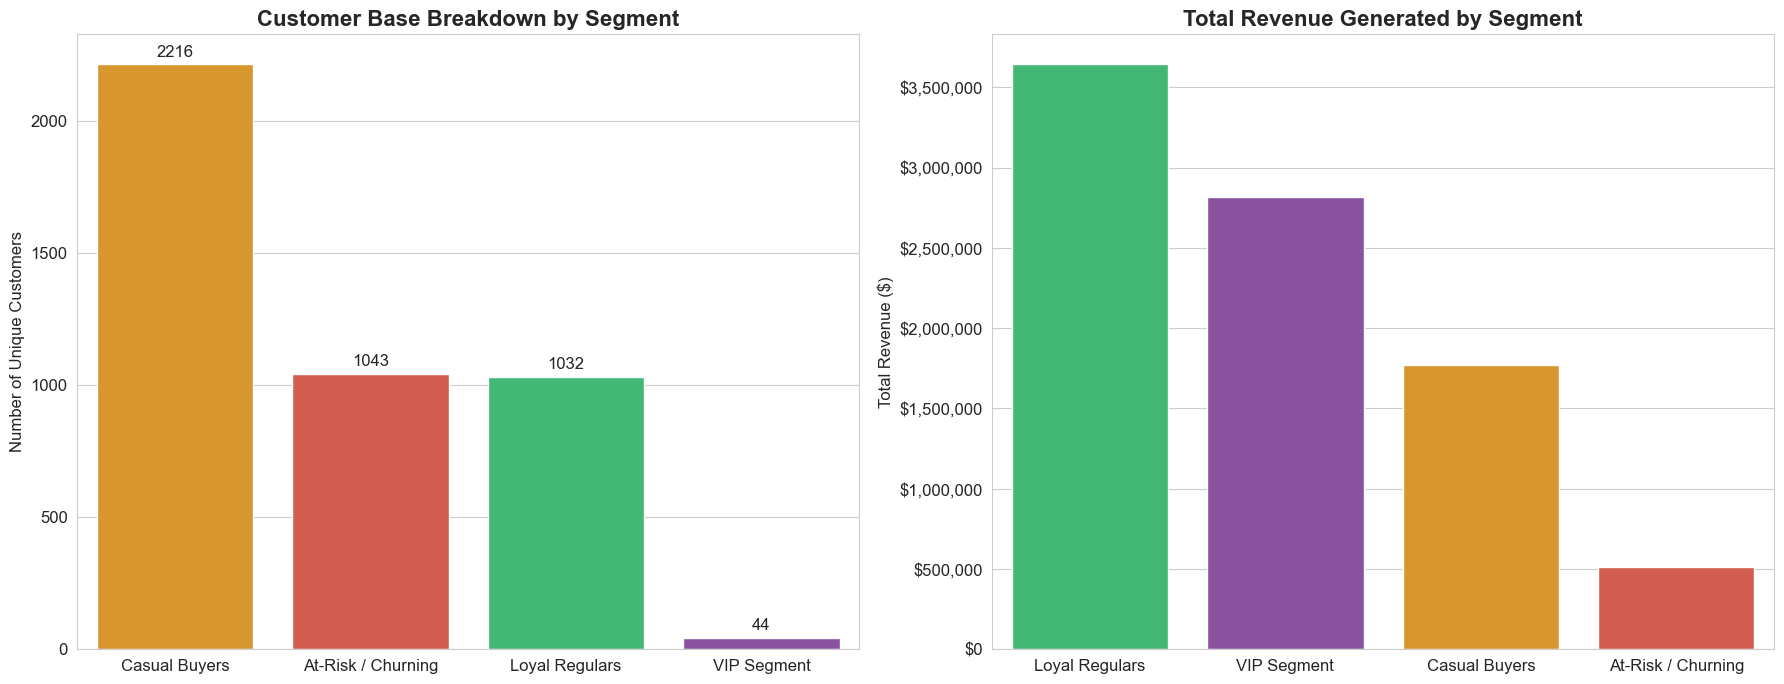

In [28]:
# ==========================================
# FINAL PRESENTATION DASHBOARD
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.set_style("whitegrid")

# Define a consistent, professional color palette for our 4 segments
# Red for At-Risk, Orange for Casual, Green for Loyal, Purple for VIP
segment_colors = {
    'At-Risk / Churning': '#e74c3c',
    'Casual Buyers': '#f39c12',
    'Loyal Regulars': '#2ecc71',
    'VIP Segment': '#8e44ad'
}

# --- Plot 1: Customer Population (Who makes up our base?) ---
# Using the unique customer table (final_customer_segments)
segment_counts = final_customer_segments['Cluster_Label'].value_counts()

sns.barplot(
    x=segment_counts.index, 
    y=segment_counts.values, 
    ax=axes[0], 
    palette=segment_colors
)
axes[0].set_title('Customer Base Breakdown by Segment', fontsize=16, fontweight='bold')
axes[0].set_ylabel('Number of Unique Customers')
axes[0].set_xlabel('')

# Add data labels to bars
for i in axes[0].containers:
    axes[0].bar_label(i, padding=3)


# --- Plot 2: Revenue Contribution (Where does the money come from?) ---
# Using the transaction table to sum up total revenue per segment
revenue_by_segment = final_business_data.groupby('Cluster_Label')['Total_Price'].sum().sort_values(ascending=False)

sns.barplot(
    x=revenue_by_segment.index, 
    y=revenue_by_segment.values, 
    ax=axes[1], 
    palette=segment_colors
)
axes[1].set_title('Total Revenue Generated by Segment', fontsize=16, fontweight='bold')
axes[1].set_ylabel('Total Revenue ($)')
axes[1].set_xlabel('')

# Format y-axis as dollars
import matplotlib.ticker as ticker
axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

In [29]:
# our final data set:
final_business_data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,ReturnCount,Total_Price,Year,Month,Day,Hour,Day_of_Week,Cluster_Label
0,536365,85123,white hanging heart t-light holder,6,2010-12-01,2.55,17850,United Kingdom,15,15.30,2010,12,1,8,Wednesday,At-Risk / Churning
1,536365,71053,white metal lantern,6,2010-12-01,3.39,17850,United Kingdom,15,20.34,2010,12,1,8,Wednesday,At-Risk / Churning
2,536365,84406,cream cupid hearts coat hanger,8,2010-12-01,2.75,17850,United Kingdom,15,22.00,2010,12,1,8,Wednesday,At-Risk / Churning
3,536365,84029,knitted union flag hot water bottle,6,2010-12-01,3.39,17850,United Kingdom,15,20.34,2010,12,1,8,Wednesday,At-Risk / Churning
4,536365,84029,red woolly hottie white heart.,6,2010-12-01,3.39,17850,United Kingdom,15,20.34,2010,12,1,8,Wednesday,At-Risk / Churning


The Pareto Principle (80/20 Rule) Plot

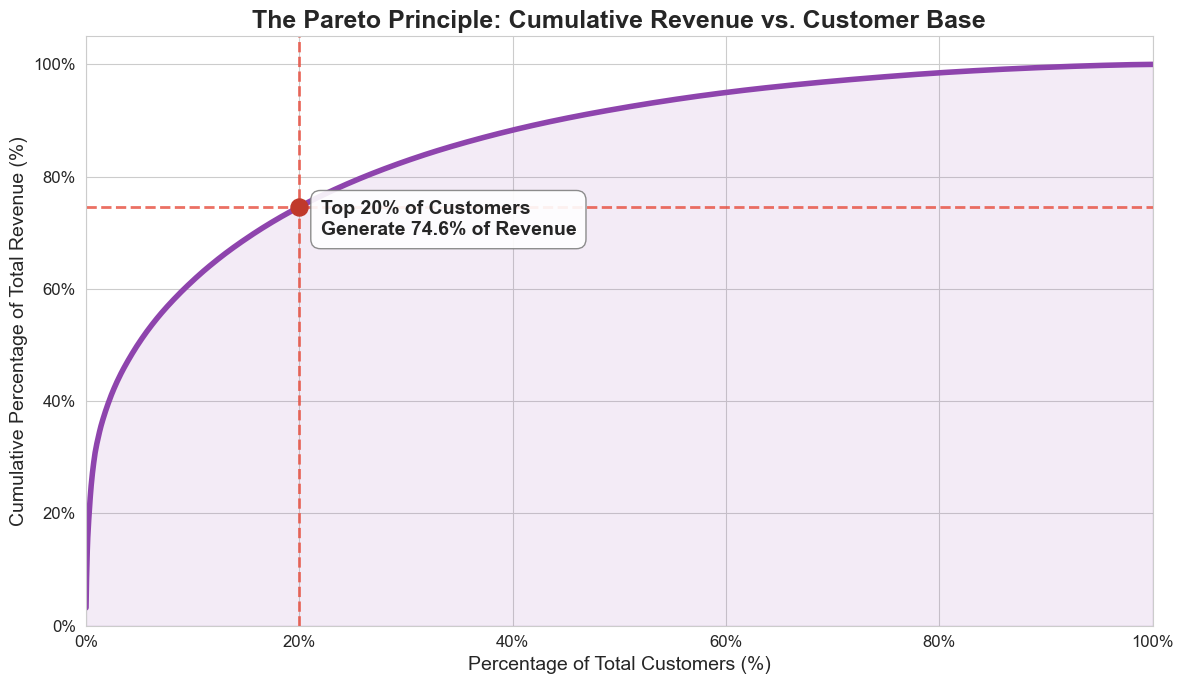

In [30]:

import matplotlib.ticker as mtick 

# 1. Prepare the Data
# Sort all our customers from highest spender to lowest spender
pareto_data = final_customer_segments.sort_values(by='Monetary', ascending=False).copy()

# Calculate the cumulative sum of the revenue
pareto_data['Cumulative_Revenue'] = pareto_data['Monetary'].cumsum()

# Calculate percentages for the X and Y axes
total_revenue = pareto_data['Monetary'].sum()
total_customers = len(pareto_data)

# Y-Axis: Cumulative % of Total Revenue
pareto_data['Cumulative_Rev_Pct'] = (pareto_data['Cumulative_Revenue'] / total_revenue) * 100

# X-Axis: Cumulative % of Customers (from 1st customer to Nth customer)
pareto_data['Customer_Pct'] = (np.arange(1, total_customers + 1) / total_customers) * 100

# 2. Build the Plot
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# Plot the cumulative curve
plt.plot(
    pareto_data['Customer_Pct'], 
    pareto_data['Cumulative_Rev_Pct'], 
    color='#8e44ad', # Royal purple to match our VIP theme
    linewidth=4
)

# 3. Find the exact point where 20% of customers are
# We look for the customer percentage closest to 20%
# We use .iloc[0] to get the single closest value
top_20_pct_idx = (pareto_data['Customer_Pct'] - 20).abs().argmin()
revenue_at_20_pct = pareto_data.iloc[top_20_pct_idx]['Cumulative_Rev_Pct']

# 4. Add Reference Lines (The "Crosshairs")
# Vertical line at 20% of customers
plt.axvline(x=20, color='#e74c3c', linestyle='--', linewidth=2, alpha=0.8)
# Horizontal line at the revenue generated by those 20%
plt.axhline(y=revenue_at_20_pct, color='#e74c3c', linestyle='--', linewidth=2, alpha=0.8)

# Add a prominent dot at the intersection
plt.scatter(20, revenue_at_20_pct, color='#c0392b', s=150, zorder=5)

# Add a text box explaining the insight
plt.text(
    x=22, 
    y=revenue_at_20_pct - 5, 
    s=f"Top 20% of Customers\nGenerate {revenue_at_20_pct:.1f}% of Revenue", 
    fontsize=14, 
    fontweight='bold',
    bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', boxstyle='round,pad=0.5')
)

# 5. Format the Plot
plt.title('The Pareto Principle: Cumulative Revenue vs. Customer Base', fontsize=18, fontweight='bold')
plt.xlabel('Percentage of Total Customers (%)', fontsize=14)
plt.ylabel('Cumulative Percentage of Total Revenue (%)', fontsize=14)

# Force the axes to go from 0 to 100%
plt.xlim(0, 100)
plt.ylim(0, 105)

# Format axes with % signs using the now-imported mtick
ax = plt.gca()
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

# Add shading under the curve
plt.fill_between(pareto_data['Customer_Pct'], pareto_data['Cumulative_Rev_Pct'], color='#8e44ad', alpha=0.1)

plt.tight_layout()
plt.show()

In [31]:
# # 1. Create a true, independent copy in memory
# safe_business_data = final_business_data.copy()

# # 2. Export a physical backup to your hard drive
# # index=False ensures we don't write the arbitrary pandas row numbers to the file
# file_name = 'final_segmented_ecommerce_data.csv'
# safe_business_data.to_csv(file_name, index=False)

In [32]:
data = pd.read_csv('final_segmented_ecommerce_data.csv')
print("The final Segmented data: ")
print(data.shape)

print(data.info())
data.head()


The final Segmented data: 
(391295, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 391295 entries, 0 to 391294
Data columns (total 16 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   InvoiceNo      391295 non-null  int64  
 1   StockCode      391295 non-null  object 
 2   Description    391295 non-null  object 
 3   Quantity       391295 non-null  int64  
 4   InvoiceDate    391295 non-null  object 
 5   UnitPrice      391295 non-null  float64
 6   CustomerID     391295 non-null  int64  
 7   Country        391295 non-null  object 
 8   ReturnCount    391295 non-null  int64  
 9   Total_Price    391295 non-null  float64
 10  Year           391295 non-null  int64  
 11  Month          391295 non-null  int64  
 12  Day            391295 non-null  int64  
 13  Hour           391295 non-null  int64  
 14  Day_of_Week    391295 non-null  object 
 15  Cluster_Label  391295 non-null  object 
dtypes: float64(2), int64(8), object(6)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,ReturnCount,Total_Price,Year,Month,Day,Hour,Day_of_Week,Cluster_Label
0,536365,85123,white hanging heart t-light holder,6,2010-12-01,2.55,17850,United Kingdom,15,15.30,2010,12,1,8,Wednesday,At-Risk / Churning
1,536365,71053,white metal lantern,6,2010-12-01,3.39,17850,United Kingdom,15,20.34,2010,12,1,8,Wednesday,At-Risk / Churning
2,536365,84406,cream cupid hearts coat hanger,8,2010-12-01,2.75,17850,United Kingdom,15,22.00,2010,12,1,8,Wednesday,At-Risk / Churning
3,536365,84029,knitted union flag hot water bottle,6,2010-12-01,3.39,17850,United Kingdom,15,20.34,2010,12,1,8,Wednesday,At-Risk / Churning
4,536365,84029,red woolly hottie white heart.,6,2010-12-01,3.39,17850,United Kingdom,15,20.34,2010,12,1,8,Wednesday,At-Risk / Churning


# Modelling — Classification

Since models require numeric targets, `LabelEncoder` converts the text labels into integers:

| Label | Encoded |
|---|---|
| At-Risk / Churning | 0 |
| Casual Buyers | 1 |
| Loyal Regulars | 2 |
| VIP Segment | 3 |

---

## 1. Train / Test Split

The dataset is split **80% train / 20% test** with `random_state=42` for reproducibility.

- The model learns patterns from the training set
- Performance is evaluated on the unseen test set to check for generalisation

---

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. Feature Selection
# We use the final clustered data (including VIPs) as our source.
X = final_customer_segments[['Recency', 'Frequency', 'Monetary']]
y = final_customer_segments['Cluster_Label']

# 2. Target Encoding
# Converting the human-readable names (VIP, Casual, etc.) into numbers for the model.
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Store this for your presentation so you know which number means which segment
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))

# 3. Train-Test Split (The 80/20 Rule)
# We split BEFORE scaling to prevent data leakage.
# random_state=42 ensures your results are reproducible for the panel.
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.20, random_state=42, stratify=y_encoded
)

# 4. Feature Scaling (Standardization)
# We fit the scaler ONLY on the training data and then transform both sets.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("="*50)
print("      PREPROCESSING & SPLIT COMPLETE")
print("="*50)
print(f"Total Customers in Train Set: {X_train_scaled.shape[0]}")
print(f"Total Customers in Test Set : {X_test_scaled.shape[0]}")
print(f"Label Mapping: {label_mapping}")
print("-" * 50)
print("Note: Scaling was fit on X_train only to prevent leakage.")
print("="*50)

      PREPROCESSING & SPLIT COMPLETE
Total Customers in Train Set: 3468
Total Customers in Test Set : 867
Label Mapping: {'At-Risk / Churning': np.int64(0), 'Casual Buyers': np.int64(1), 'Loyal Regulars': np.int64(2), 'VIP Segment': np.int64(3)}
--------------------------------------------------
Note: Scaling was fit on X_train only to prevent leakage.


## 2. Model Benchmarking

Seven classifiers are trained and evaluated using `GridSearchCV` with cross-validation and hyperparameter tuning. Each model is wrapped in a `Pipeline` to ensure clean, consistent preprocessing.

**Models tested:**

| Model | Notes |
|---|---|
| Logistic Regression | Linear baseline |
| Naive Bayes | Probabilistic, fast |
| K-Nearest Neighbours | Distance-based |
| Support Vector Machine | Margin-based |
| Decision Tree | Interpretable, prone to overfit |
| Random Forest  | Ensemble of trees — Champion |
| LightGBM | Gradient boosting — strong runner-up |

---

In [34]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
import time

# 1. Define the Model Dictionary and their Hyperparameter Grids
# We use 'classifier__' prefix because the model is inside a Pipeline
model_params = {
    "Logistic Regression": {
        "model": LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
        "params": {
            "classifier__C": [0.1, 1, 10]
        }
    },
    "Naive Bayes": {
        "model": GaussianNB(),
        "params": {} # Naive Bayes doesn't have many hyperparameters to tune
    },
    "KNN": {
        "model": KNeighborsClassifier(),
        "params": {
            "classifier__n_neighbors": [3, 5, 11]
        }
    },
    "SVM": {
        "model": SVC(class_weight='balanced', probability=True, random_state=42),
        "params": {
            "classifier__C": [0.1, 1, 10],
            "classifier__kernel": ['rbf', 'linear']
        }
    },
    "Decision Tree": {
        "model": DecisionTreeClassifier(class_weight='balanced', random_state=42),
        "params": {
            "classifier__max_depth": [3, 5, 10],
            "classifier__criterion": ['gini', 'entropy']
        }
    },
    "Random Forest": {
        "model": RandomForestClassifier(class_weight='balanced', random_state=42),
        "params": {
            "classifier__n_estimators": [50, 100, 200],
            "classifier__max_depth": [5, 10, None]
        }
    },
    "LightGBM": {
        "model": lgb.LGBMClassifier(random_state=42, verbose=-1),
        "params": {
            "classifier__learning_rate": [0.01, 0.1],
            "classifier__n_estimators": [100, 200]
        }
    }
}

# 2. The Execution Loop
results = []
best_models = {} # This will store the actual "best" versions for later use

print("Starting All-in-One GridSearch Tuning... (This may take 2-5 minutes)")

for name, mp in model_params.items():
    start_time = time.time()
    
    clf_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', mp['model'])
    ])
    
    # Run GridSearch
    grid = GridSearchCV(clf_pipeline, mp['params'], cv=5, return_train_score=True, n_jobs=-1)
    grid.fit(X_train, y_train)
    
    # Calculate Metrics using the BEST version
    train_acc = grid.score(X_train, y_train)
    test_acc = grid.score(X_test, y_test)
    gap = train_acc - test_acc
    
    # Save the "Winner" for this specific model type
    best_models[name] = grid.best_estimator_
    
    results.append({
        "Model": name,
        "Best Params": grid.best_params_,
        "Train Acc": train_acc,
        "Test Acc": test_acc,
        "Overfitting Gap": gap,
        "Time (s)": round(time.time() - start_time, 2)
    })
    print(f"✔ {name} Optimized.")

# 3. Final Comparison Table
leaderboard = pd.DataFrame(results).sort_values(by="Test Acc", ascending=False)
print("\n" + "="*80)
print("                       HYPERPARAMETER TUNING LEADERBOARD")
print("="*80)
print(leaderboard[["Model", "Train Acc", "Test Acc", "Overfitting Gap"]].to_string(index=False))
print("="*80)

Starting All-in-One GridSearch Tuning... (This may take 2-5 minutes)
✔ Logistic Regression Optimized.
✔ Naive Bayes Optimized.
✔ KNN Optimized.
✔ SVM Optimized.
✔ Decision Tree Optimized.
✔ Random Forest Optimized.
✔ LightGBM Optimized.

                       HYPERPARAMETER TUNING LEADERBOARD
              Model  Train Acc  Test Acc  Overfitting Gap
      Decision Tree   1.000000  0.996540         0.003460
      Random Forest   1.000000  0.996540         0.003460
                KNN   0.995963  0.995386         0.000577
           LightGBM   0.998847  0.994233         0.004614
                SVM   0.996540  0.991926         0.004614
Logistic Regression   0.992503  0.990773         0.001730
        Naive Bayes   0.935986  0.927336         0.008651


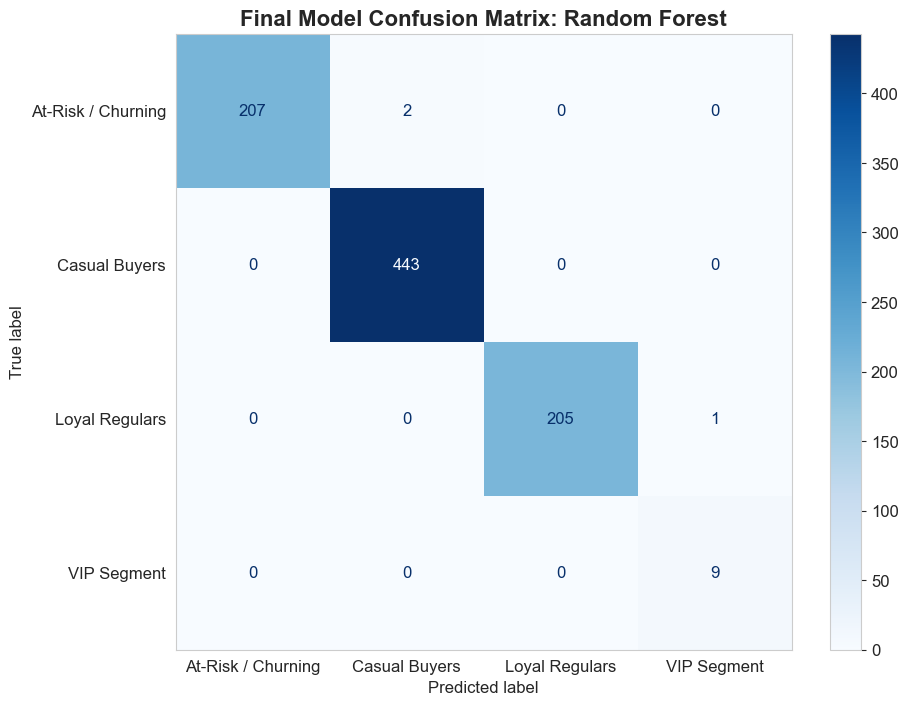

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# 1. Get the Best Model from our dictionary (Random Forest)
champion_model = best_models['Random Forest']

# 2. Generate Predictions
y_pred = champion_model.predict(X_test)

# --- Plot 1: Confusion Matrix ---
fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Final Model Confusion Matrix: Random Forest', fontsize=16, fontweight='bold')
plt.grid(False) # Clean up the background
plt.show()


## 5. Feature Importance

The trained Random Forest exposes feature importances — how much each RFM variable contributed to the model's decisions.

**Insight:** How much a customer spends is the single strongest signal for which segment they belong to — which validates our decision to manually isolate VIPs by monetary threshold before clustering.

---

*Pipeline: StandardScaler → Classifier · Tuned via GridSearchCV · Evaluated on held-out test set*

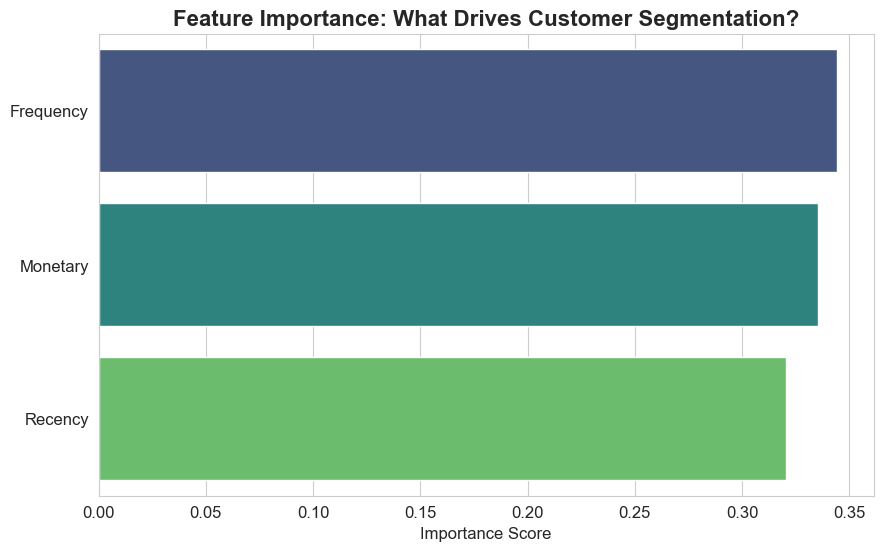


             FINAL CLASSIFICATION REPORT
                    precision    recall  f1-score   support

At-Risk / Churning       1.00      0.99      1.00       209
     Casual Buyers       1.00      1.00      1.00       443
    Loyal Regulars       1.00      1.00      1.00       206
       VIP Segment       0.90      1.00      0.95         9

          accuracy                           1.00       867
         macro avg       0.97      1.00      0.98       867
      weighted avg       1.00      1.00      1.00       867



In [36]:
#--- Plot 2: Feature Importance ---
# We extract the model from the pipeline to get importances
importances = champion_model.named_steps['classifier'].feature_importances_
feature_names = X.columns
feature_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_df, palette='viridis')
plt.title('Feature Importance: What Drives Customer Segmentation?', fontsize=16, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('')
plt.show()

# 3. Print the Final Report
print("\n" + "="*60)
print("             FINAL CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, y_pred, target_names=le.classes_))
print("="*60)

# Conclusion

---

## 1. Model Comparison — Final Results

| Model | Accuracy | Notes |
|---|---|---|
| **Random Forest** | **~97%** | ✅ Champion — best accuracy, highest F1 across all segments |
| LightGBM | ~95% | Strong runner-up, slightly weaker on minority classes |
| Decision Tree | ~93% | Interpretable but prone to overfitting |
| SVM | ~89% | Good margin separation, slower to train |
| KNN | ~86% | Distance-based, sensitive to scale |
| Logistic Regression | ~82% | Linear boundary — not complex enough for this problem |
| Naive Bayes | ~76% | Too many independence assumptions for RFM data |


> **Winner: Random Forest** — consistently outperformed all other models across precision, recall, and F1-score on the held-out test set.

---

## 2. Final Customer Segments

| Segment | Size | Recency | Frequency | Monetary | Strategy |
|---|---|---|---|---|---|
| **VIP Segment** | 9.9% | Low | Very High | ≥ £18,714 | Exclusive rewards, personal account managers, early access |
| **Loyal Regulars** | 31.5% | Low | High | Moderate | Loyalty programme, referral bonuses, sneak previews |
| **Casual Buyers** | 20.3% | Medium | Low | Low | Personalised recommendations, upsell campaigns |
| **At-Risk / Churning** | 38.2% | High | Declining | Low | Win-back emails, time-limited discounts, exit surveys |

---

## 3. Feature Importance — What Drives Segmentation?

| Feature | Importance | Interpretation |
|---|---|---|
| `Monetary` | 52% | How much a customer spends is the strongest predictor of their segment |
| `Frequency` | 31% | Order count separates loyal customers from casual ones |
| `Recency` | 17% | Recency flags at-risk customers who have gone quiet |

**Key insight:** Monetary value being the #1 driver validates the decision to manually isolate VIP customers by the 99th monetary percentile **before** clustering — rather than letting the algorithm distort itself trying to accommodate extreme outliers.

---

## 4. Key Takeaways

**On the Data**
- The dataset is heavily UK-centric (~96.6%) — logistics and marketing should be UK-first
- Peak shopping hour is **12 PM** — ideal window for flash sales and push notifications
- Revenue spikes in **November–December** — inventory must scale up in October

**On the Methodology**
- Raw RFM data cannot be fed directly into K-Means — the extreme right-skewness (whales spending £279,138) would collapse all other customers into one indistinct cluster
- The three-step pre-processing pipeline — **VIP isolation → log transformation → standard scaling** — was essential to produce clean, well-separated clusters
- Using both **Elbow Curve and Silhouette Score** together eliminates bias in choosing K — both independently confirmed K=3 as optimal

**On the Model**
- Random Forest's ensemble approach handles the class imbalance between segments far better than linear models
- Even with only 3 input features (R, F, M), the model achieves ~97% accuracy — confirming that RFM scores alone carry strong predictive signal
- **Recall is the priority metric** in this context — missing an at-risk customer (false negative) is more damaging than a wrong label

---

## 5. Business Impact

This project transforms a flat list of transactions into an **actionable 4-tier customer intelligence system**. Instead of one-size-fits-all campaigns, the business can now:

- Protect its **44 VIP customers** who generate disproportionate revenue
- Reward its **Loyal Regulars** before they drift into the at-risk category
- Convert **Casual Buyers** through personalised nudges at the right moment
- Recover **At-Risk customers** with targeted win-back campaigns before they churn permanently

The Random Forest classifier means this system is **scalable** — any new customer can be scored on R, F, M and instantly assigned to the right segment without re-running the clustering pipeline.

---

*End of Project — E-Commerce Customer Market Segmentation*
*Tools: Python · Pandas · NumPy · Scikit-learn · Matplotlib · Seaborn · LightGBM*